 # RetailRocket — Drift Stress Test 




 **Drift scenarios for next-parent (3):**



 1. **Repeat-row drift** — 5,000 consecutive duplicates of one event.

 2. **Category-shuffle drift** — random permutation of all subsequent

    `parent_category` values.

 3. **Distribution-shift drift** — 80% of post-drift events have their

    parent overwritten with one of the top-5 popular pre-drift categories.



 **Drift scenarios for intent (2):**



 1. **Intent suppression** — ~50% of post-drift transactions flipped to views.

 2. **Intent boost** — ~5% of post-drift views flipped to transactions.



 **Models tested per task:**



 - **Next parent:** Last seen, Transition matrix, ARF Big, ARF Lean, HAT, Hybrid

   (all with trending-cold-start fallback; all score on every event)

 - **Intent:** Always-zero, Cart heuristic, ARF Big, ARF Lean, HAT

   (ML models wrapped in RandomOverSampler; all score on every event)

 ## 1. Imports and configuration

In [1]:
import os, copy, math, random
from collections import deque, Counter, defaultdict

import matplotlib.pyplot as plt

from river import (
    stream, forest, tree, imblearn, metrics, anomaly, stats,
)

TABLE2_PATH = '/Users/maciej/Desktop/MLDS_workspace/data_retailrocket/table2_stream.csv'
PLOT_DIR    = '/Users/maciej/Desktop/MLDS_workspace/data_retailrocket/plots_drift_v3'
os.makedirs(PLOT_DIR, exist_ok=True)

TOTAL_ROWS          = 200_000
DRIFT_POINT         = 100_000
LOG_EVERY           = 5_000
GLOBAL_WINDOW       = 2_000
GRAPH_EDGES         = 5_000
HYBRID_THRESHOLD    = 0.1
SESSION_GAP_SECONDS = 30 * 60
EVENT_WEIGHTS       = {'view': 1.0, 'addtocart': 3.0, 'transaction': 5.0}


 ## 2. Helpers and converters

In [2]:
def safe_float(val):
    return float(val) if val != '' else None

converters = {
    'timestamp': int, 'visitorid': int, 'itemid': int,
    'parent_category': safe_float, 'property_790': safe_float,
}


 ## 3. Load base stream into memory

In [3]:
def load_rows(n=TOTAL_ROWS):
    rows = []
    for i, (x, _) in enumerate(stream.iter_csv(TABLE2_PATH, target=None, converters=converters)):
        if i >= n:
            break
        rows.append(x)
    return rows

print("Loading base stream into memory...")
BASE_ROWS = load_rows()
print(f"Loaded {len(BASE_ROWS):,} rows.\n")


Loading base stream into memory...
Loaded 200,000 rows.



 ## 4. Drift stream generators

 ### 4a. Next-parent drift scenarios

In [4]:
def repeat_row_drift(base_rows, drift_at=DRIFT_POINT, repeat_len=5_000):
    rows = copy.deepcopy(base_rows)
    if drift_at >= len(rows):
        return rows
    template = copy.deepcopy(rows[drift_at])
    end = min(drift_at + repeat_len, len(rows))
    for j in range(drift_at, end):
        rows[j] = copy.deepcopy(template)
    return rows


def category_shuffle_drift(base_rows, drift_at=DRIFT_POINT, seed=42):
    rows = copy.deepcopy(base_rows)
    cats = sorted({r['parent_category'] for r in rows if r['parent_category'] is not None})
    rng = random.Random(seed)
    shuffled = cats[:]
    rng.shuffle(shuffled)
    perm = dict(zip(cats, shuffled))
    for j in range(drift_at, len(rows)):
        c = rows[j]['parent_category']
        if c is not None:
            rows[j]['parent_category'] = perm[c]
    return rows


def distribution_shift_drift(base_rows, drift_at=DRIFT_POINT, seed=42, dominate_frac=0.8):
    rows = copy.deepcopy(base_rows)
    pre_counts = Counter()
    for r in rows[:drift_at]:
        if r['parent_category'] is not None:
            pre_counts[r['parent_category']] += 1
    top5 = [c for c, _ in pre_counts.most_common(5)]
    rng = random.Random(seed)
    for j in range(drift_at, len(rows)):
        if rows[j]['parent_category'] is not None and rng.random() < dominate_frac:
            rows[j]['parent_category'] = rng.choice(top5)
    return rows


 ### 4b. Intent drift scenarios

In [5]:
def intent_suppression_drift(base_rows, drift_at=DRIFT_POINT, seed=42, flip_frac=0.5):
    rows = copy.deepcopy(base_rows)
    rng = random.Random(seed)
    for j in range(drift_at, len(rows)):
        if rows[j].get('event') == 'transaction' and rng.random() < flip_frac:
            rows[j]['event'] = 'view'
    return rows


def intent_boost_drift(base_rows, drift_at=DRIFT_POINT, seed=42, boost_frac=0.05):
    rows = copy.deepcopy(base_rows)
    rng = random.Random(seed)
    for j in range(drift_at, len(rows)):
        if rows[j].get('event') == 'view' and rng.random() < boost_frac:
            rows[j]['event'] = 'transaction'
    return rows


 ## 5. Cold-start strategies

In [6]:
class GlobalTrendingColdStart:
    def __init__(self, window_size=GLOBAL_WINDOW):
        self.history = deque(maxlen=window_size)
        self.counts = Counter()

    def predict(self):
        if not self.counts:
            return None, 0.0
        top, count = self.counts.most_common(1)[0]
        total = sum(self.counts.values())
        return top, count / total

    def proba_dict(self):
        if not self.counts:
            return {}
        total = sum(self.counts.values())
        return {cat: c / total for cat, c in self.counts.items()}

    def update(self, category):
        if category is None:
            return
        if len(self.history) == self.history.maxlen:
            old = self.history[0]
            self.counts[old] -= 1
            if self.counts[old] == 0:
                del self.counts[old]
        self.history.append(category)
        self.counts[category] += 1


class IntentColdStart:
    def __init__(self):
        self.n_total = 0
        self.n_transactions = 0

    def base_rate(self):
        if self.n_total == 0:
            return 0.0081
        return self.n_transactions / self.n_total

    def update(self, y_intent):
        self.n_total += 1
        self.n_transactions += y_intent


 ## 6. Stateful feature components (item-hidden setup)

In [7]:
class PatternMiner:
    def __init__(self, global_window_size=GLOBAL_WINDOW, per_user_window=5):
        self.visitor_history = defaultdict(lambda: deque(maxlen=per_user_window))
        self.global_history = deque(maxlen=global_window_size)
        self.global_counts = Counter()
        self.global_window_size = global_window_size

    def last_seen(self, v):
        h = self.visitor_history[v]
        return h[-1] if h else -1

    def diversity(self, v):
        return len(set(self.visitor_history[v]))

    def trending_score(self, c):
        if c is None or c == -1:
            return 0.0
        return self.global_counts.get(c, 0) / max(1, len(self.global_history))

    def update(self, v, c):
        if c is None:
            return
        self.visitor_history[v].append(c)
        if len(self.global_history) == self.global_window_size:
            old = self.global_history[0]
            self.global_counts[old] -= 1
            if self.global_counts[old] == 0:
                del self.global_counts[old]
        self.global_history.append(c)
        self.global_counts[c] += 1


class TransitionMatrix:
    def __init__(self):
        self.transitions = defaultdict(Counter)
        self.last_for_user = {}

    def predict(self, v):
        last = self.last_for_user.get(v)
        if last is None:
            return None, 0.0
        counts = self.transitions.get(last)
        if not counts:
            return None, 0.0
        top, c = counts.most_common(1)[0]
        return top, c / sum(counts.values())

    def proba_dict(self, v):
        last = self.last_for_user.get(v)
        if last is None:
            return {}
        counts = self.transitions.get(last)
        if not counts:
            return {}
        total = sum(counts.values())
        return {cls: c / total for cls, c in counts.items()}

    def features(self, v):
        _, prob = self.predict(v)
        return {'transition_top_prob': prob}

    def update(self, v, c):
        if c is None:
            return
        last = self.last_for_user.get(v)
        if last is not None:
            self.transitions[last][c] += 1
        self.last_for_user[v] = c


class UserSessionTracker:
    def __init__(self, gap_s=SESSION_GAP_SECONDS):
        self.event_counts = defaultdict(Counter)
        self.last_timestamp = {}
        self.session_event_count = defaultdict(int)
        self.gap_s = gap_s

    def features(self, v, ts):
        c = self.event_counts[v]
        last_ts = self.last_timestamp.get(v)
        if last_ts is None:
            time_since = -1.0
            is_new_session = 1.0
        else:
            time_since = (ts - last_ts) / 1000.0
            is_new_session = 1.0 if time_since > self.gap_s else 0.0
        view, cart, trans = c.get('view', 0), c.get('addtocart', 0), c.get('transaction', 0)
        return {
            'prior_view_count': float(view),
            'prior_cart_count': float(cart),
            'prior_transaction_count': float(trans),
            'cart_to_view_ratio': cart / max(1, view),
            'log_time_since_last': math.log1p(max(0.0, time_since)) if time_since >= 0 else -1.0,
            'is_new_session': is_new_session,
            'events_in_session': float(self.session_event_count[v]),
        }

    def update(self, v, ev, ts):
        last_ts = self.last_timestamp.get(v)
        if last_ts is not None and (ts - last_ts) / 1000.0 > self.gap_s:
            self.session_event_count[v] = 0
        self.session_event_count[v] += 1
        self.event_counts[v][ev] += 1
        self.last_timestamp[v] = ts


class WeightedBipartiteGraph:
    """Only USER-SIDE features are exposed at prediction time."""

    def __init__(self, max_edges=GRAPH_EDGES):
        self.edges = deque(maxlen=max_edges)
        self.user_to_items = defaultdict(lambda: defaultdict(float))
        self.item_to_users = defaultdict(lambda: defaultdict(float))

    def user_features(self, v):
        return {
            'user_degree': float(len(self.user_to_items[v])),
            'user_total_weight': sum(self.user_to_items[v].values()),
        }

    def update(self, v, item, ev):
        w = EVENT_WEIGHTS.get(ev, 1.0)
        if len(self.edges) == self.edges.maxlen:
            ou, oi, ow = self.edges[0]
            self.user_to_items[ou][oi] -= ow
            if self.user_to_items[ou][oi] <= 1e-9:
                del self.user_to_items[ou][oi]
            self.item_to_users[oi][ou] -= ow
            if self.item_to_users[oi][ou] <= 1e-9:
                del self.item_to_users[oi][ou]
        self.edges.append((v, item, w))
        self.user_to_items[v][item] += w
        self.item_to_users[item][v] += w


 ## 7. Lean feature views

In [8]:
LEAN_PARENT_KEYS = (
    'last_seen_parent', 'transition_top_prob',
    'prior_view_count', 'is_new_session', 'log_time_since_last',
)

LEAN_INTENT_KEYS = (
    'prior_view_count', 'prior_cart_count', 'prior_transaction_count',
    'cart_to_view_ratio', 'is_new_session',
)

def slice_lean(x, keys):
    return {k: x[k] for k in keys if k in x}

def wrap_oversample(clf):
    return imblearn.RandomOverSampler(
        classifier=clf, desired_dist={0: 0.7, 1: 0.3}, seed=42)


 ## 8. Next-parent scenario runner

In [9]:
def run_parent_scenario(rows, scenario_name, drift_point):
    print(f"\n--- [Next parent] Running scenario: {scenario_name} ---")

    # Fresh state
    transition  = TransitionMatrix()
    pattern     = PatternMiner()
    session     = UserSessionTracker()
    graph       = WeightedBipartiteGraph()
    hst         = anomaly.HalfSpaceTrees(n_trees=25, height=15, window_size=250, seed=42)
    trending    = GlobalTrendingColdStart()
    last_seen_per_user = {}

    arf_big  = forest.ARFClassifier(n_models=15, seed=42)
    arf_lean = forest.ARFClassifier(n_models=5, max_depth=8, seed=42)
    hat      = tree.HoeffdingAdaptiveTreeClassifier(grace_period=200, delta=1e-5, seed=42)

    m = {k: metrics.Accuracy() for k in
         ['last_seen', 'transition', 'arf_big', 'arf_lean', 'hat', 'hybrid']}
    history = {k: [] for k in m}
    history['rows'] = []

    for i, x_raw in enumerate(rows):
        y_event   = x_raw.get('event')
        y_parent  = x_raw.get('parent_category')
        visitor_id = x_raw.get('visitorid')
        item_id    = x_raw.get('itemid')
        current_ts = x_raw.get('timestamp', 0)
        hour_of_day = (current_ts // 3_600_000) % 24

        # Engineered features (USER & GLOBAL ONLY — no item info)
        sess_feats   = session.features(visitor_id, current_ts)
        trans_feats  = transition.features(visitor_id)
        user_graph   = graph.user_features(visitor_id)
        last_seen_p  = pattern.last_seen(visitor_id)
        diversity    = float(pattern.diversity(visitor_id))

        base_numeric = {**sess_feats, **user_graph}
        anomaly_score = hst.score_one(base_numeric)
        hst.learn_one(base_numeric)

        x_full = {
            **sess_feats, **trans_feats, **user_graph,
            'last_seen_parent':  last_seen_p,
            'recent_diversity':  diversity,
            'anomaly_score':     anomaly_score,
            'hour_of_day':       float(hour_of_day),
            'trending_last_seen': pattern.trending_score(last_seen_p),
        }
        x_lean = slice_lean(x_full, LEAN_PARENT_KEYS)

        if y_parent is not None:
            trend_pred, _ = trending.predict()

            # Last seen
            ls_pred = last_seen_per_user.get(visitor_id)
            if ls_pred is None:
                ls_pred = trend_pred
            if ls_pred is not None:
                m['last_seen'].update(y_parent, ls_pred)
            last_seen_per_user[visitor_id] = y_parent

            # Transition matrix
            tm_pred, tm_prob = transition.predict(visitor_id)
            if tm_pred is None:
                tm_pred = trend_pred
            if tm_pred is not None:
                m['transition'].update(y_parent, tm_pred)

            # ARF Big
            big_pred = arf_big.predict_one(x_full)
            if big_pred is None:
                big_pred = trend_pred
            if big_pred is not None:
                m['arf_big'].update(y_parent, big_pred)
            arf_big.learn_one(x_full, y_parent)

            # ARF Lean
            lean_pred = arf_lean.predict_one(x_lean)
            if lean_pred is None:
                lean_pred = trend_pred
            if lean_pred is not None:
                m['arf_lean'].update(y_parent, lean_pred)
            arf_lean.learn_one(x_lean, y_parent)

            # HAT
            hat_pred = hat.predict_one(x_lean)
            if hat_pred is None:
                hat_pred = trend_pred
            if hat_pred is not None:
                m['hat'].update(y_parent, hat_pred)
            hat.learn_one(x_lean, y_parent)

            # Hybrid: TM if confident, else ARF Lean, else trending
            tm_pred_raw, tm_prob_raw = transition.predict(visitor_id)
            if tm_pred_raw is not None and tm_prob_raw >= HYBRID_THRESHOLD:
                hybrid_pred = tm_pred_raw
            elif lean_pred is not None:
                hybrid_pred = lean_pred
            else:
                hybrid_pred = trend_pred
            if hybrid_pred is not None:
                m['hybrid'].update(y_parent, hybrid_pred)

        # Update stateful components LAST
        pattern.update(visitor_id, y_parent)
        transition.update(visitor_id, y_parent)
        session.update(visitor_id, y_event, current_ts)
        graph.update(visitor_id, item_id, y_event)
        trending.update(y_parent)

        if (i + 1) % LOG_EVERY == 0:
            history['rows'].append(i + 1)
            for k in m:
                history[k].append(m[k].get())

    print(f"Final accuracies for {scenario_name}:")
    for k, v in m.items():
        print(f"  {k:>11}: {v.get():.4f}")

    return history, drift_point


 ## 9. Intent scenario runner

In [10]:
def run_intent_scenario(rows, scenario_name, drift_point):
    print(f"\n--- [Intent] Running scenario: {scenario_name} ---")

    transition = TransitionMatrix()
    pattern    = PatternMiner()
    session    = UserSessionTracker()
    graph      = WeightedBipartiteGraph()
    hst        = anomaly.HalfSpaceTrees(n_trees=25, height=15, window_size=250, seed=42)
    intent_cs  = IntentColdStart()

    arf_big  = wrap_oversample(forest.ARFClassifier(n_models=15, seed=42))
    arf_lean = wrap_oversample(forest.ARFClassifier(n_models=5, max_depth=8, seed=42))
    hat      = wrap_oversample(tree.HoeffdingAdaptiveTreeClassifier(
                  grace_period=200, delta=1e-5, seed=42))

    m = {k: {'roc': metrics.ROCAUC(), 'f1': metrics.F1()}
         for k in ['zero', 'cart', 'arf_big', 'arf_lean', 'hat']}
    history = {f'{k}_{met}': [] for k in m for met in ('roc', 'f1')}
    history['rows'] = []

    for i, x_raw in enumerate(rows):
        y_event   = x_raw.get('event')
        y_parent  = x_raw.get('parent_category')
        y_intent  = 1 if y_event == 'transaction' else 0
        visitor_id = x_raw.get('visitorid')
        item_id    = x_raw.get('itemid')
        current_ts = x_raw.get('timestamp', 0)
        hour_of_day = (current_ts // 3_600_000) % 24

        sess_feats   = session.features(visitor_id, current_ts)
        trans_feats  = transition.features(visitor_id)
        user_graph   = graph.user_features(visitor_id)
        last_seen_p  = pattern.last_seen(visitor_id)
        diversity    = float(pattern.diversity(visitor_id))

        base_numeric = {**sess_feats, **user_graph}
        anomaly_score = hst.score_one(base_numeric)
        hst.learn_one(base_numeric)

        x_full = {
            **sess_feats, **trans_feats, **user_graph,
            'last_seen_parent':  last_seen_p,
            'recent_diversity':  diversity,
            'anomaly_score':     anomaly_score,
            'hour_of_day':       float(hour_of_day),
            'trending_last_seen': pattern.trending_score(last_seen_p),
        }
        x_lean = slice_lean(x_full, LEAN_INTENT_KEYS)

        base_rate = intent_cs.base_rate()

        # Always-zero
        m['zero']['roc'].update(y_intent, 0.0)
        m['zero']['f1'].update(y_intent, 0)

        # Cart heuristic
        cart_present = sess_feats['prior_cart_count'] > 0
        m['cart']['roc'].update(y_intent, 1.0 if cart_present else 0.0)
        m['cart']['f1'].update(y_intent, int(cart_present))

        # ML models
        for key, model, x_view in [
            ('arf_big',  arf_big,  x_full),
            ('arf_lean', arf_lean, x_lean),
            ('hat',      hat,      x_lean),
        ]:
            proba = model.predict_proba_one(x_view)
            cls   = model.predict_one(x_view)
            if proba:
                m[key]['roc'].update(y_intent, proba.get(1, 0.0))
            else:
                m[key]['roc'].update(y_intent, base_rate)
            if cls is not None:
                m[key]['f1'].update(y_intent, cls)
            else:
                m[key]['f1'].update(y_intent, 0)
            model.learn_one(x_view, y_intent)

        # State updates
        pattern.update(visitor_id, y_parent)
        transition.update(visitor_id, y_parent)
        session.update(visitor_id, y_event, current_ts)
        graph.update(visitor_id, item_id, y_event)
        intent_cs.update(y_intent)

        if (i + 1) % LOG_EVERY == 0:
            history['rows'].append(i + 1)
            for k in m:
                for met in ('roc', 'f1'):
                    history[f'{k}_{met}'].append(m[k][met].get())

    print(f"Final intent metrics for {scenario_name}:")
    for k in m:
        print(f"  {k:>9}: ROC={m[k]['roc'].get():.4f}  F1={m[k]['f1'].get():.4f}")

    return history, drift_point


 ## 10. Plotting

In [14]:
PARENT_STYLE = {
    'last_seen':  ('Last seen + trending fallback',  'gray',    '--', 1.5),
    'transition': ('Transition + trending fallback', 'black',   '--', 1.5),
    'arf_big':    ('ARF Big',                        '#1f77b4', '-',  2.0),
    'arf_lean':   ('ARF Lean',                       '#ff7f0e', '-',  2.0),
    'hat':        ('HAT',                            '#2ca02c', '-',  2.0),
    'hybrid':     ('Hybrid',                         '#d62728', '-',  2.5),
}

INTENT_STYLE = {
    'zero':     ('Always-zero (baseline)',     'gray',    '--', 1.5),
    'cart':     ('Cart heuristic (baseline)',  'black',   '--', 1.5),
    'arf_big':  ('ARF Big',                    '#1f77b4', '-',  2.0),
    'arf_lean': ('ARF Lean',                   '#ff7f0e', '-',  2.0),
    'hat':      ('HAT',                        '#2ca02c', '-',  2.0),
}

def plot_parent(history, drift_point, scenario_name, filename):
    fig, ax = plt.subplots(figsize=(12, 6.5))
    rows = history['rows']
    for key, (label, color, ls, lw) in PARENT_STYLE.items():
        ax.plot(rows, history[key], label=label, color=color, linestyle=ls, linewidth=lw)
    ax.axvline(drift_point, color='red', linestyle=':', alpha=0.7, linewidth=2,
               label=f'Drift @ {drift_point:,}')
    ax.set_xlabel('Events processed')
    ax.set_ylabel('Top-1 Accuracy')
    ax.set_title(f'Next parent — {scenario_name}')
    ax.legend(loc='best', frameon=True, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, filename), dpi=150)
    plt.show()


def plot_intent(history, drift_point, scenario_name, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    rows = history['rows']
    for ax, suffix, ylabel, subtitle in [
        (ax1, 'roc', 'ROC-AUC',  'ROC-AUC'),
        (ax2, 'f1',  'F1 score', 'F1'),
    ]:
        for key, (label, color, ls, lw) in INTENT_STYLE.items():
            ax.plot(rows, history[f'{key}_{suffix}'], label=label,
                    color=color, linestyle=ls, linewidth=lw)
        ax.axvline(drift_point, color='red', linestyle=':', alpha=0.7, linewidth=2,
                   label=f'Drift @ {drift_point:,}')
        ax.set_xlabel('Events processed')
        ax.set_ylabel(ylabel)
        ax.set_title(f'Intent — {scenario_name} ({subtitle})')
        ax.legend(loc='best', frameon=True, fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)
    plt.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, filename), dpi=150)
    plt.show()


def before_after_table_parent(history, drift_point, scenario_name):
    rows = history['rows']
    pre_idx  = max(i for i, r in enumerate(rows) if r <= drift_point)
    post_idx = min(len(rows) - 1, pre_idx + len(rows) // 8)
    print(f"\n=== [Next parent] {scenario_name} — accuracy snapshots ===")
    print(f"{'Model':<12} | {'Pre-drift':>10} | {'Post-drift':>10} | {'Final':>10}")
    print('-' * 53)
    for key in PARENT_STYLE:
        pre   = history[key][pre_idx]
        post  = history[key][post_idx]
        final = history[key][-1]
        print(f"{key:<12} | {pre:>10.4f} | {post:>10.4f} | {final:>10.4f}")


def before_after_table_intent(history, drift_point, scenario_name):
    rows = history['rows']
    pre_idx  = max(i for i, r in enumerate(rows) if r <= drift_point)
    post_idx = min(len(rows) - 1, pre_idx + len(rows) // 8)
    print(f"\n=== [Intent] {scenario_name} — ROC-AUC snapshots ===")
    print(f"{'Model':<10} | {'Pre-drift':>10} | {'Post-drift':>10} | {'Final':>10}")
    print('-' * 51)
    for key in INTENT_STYLE:
        pre   = history[f'{key}_roc'][pre_idx]
        post  = history[f'{key}_roc'][post_idx]
        final = history[f'{key}_roc'][-1]
        print(f"{key:<10} | {pre:>10.4f} | {post:>10.4f} | {final:>10.4f}")


 ## 11. Run all next-parent scenarios


--- [Next parent] Running scenario: Repeat-row drift (mild) ---
Final accuracies for Repeat-row drift (mild):
    last_seen: 0.4548
   transition: 0.4532
      arf_big: 0.1654
     arf_lean: 0.1739
          hat: 0.1002
       hybrid: 0.4539

--- [Next parent] Running scenario: Category-shuffle drift (medium) ---
Final accuracies for Category-shuffle drift (medium):
    last_seen: 0.4317
   transition: 0.4300
      arf_big: 0.1329
     arf_lean: 0.1539
          hat: 0.0789
       hybrid: 0.4310

--- [Next parent] Running scenario: Distribution-shift drift (severe) ---
Final accuracies for Distribution-shift drift (severe):
    last_seen: 0.3057
   transition: 0.3042
      arf_big: 0.1507
     arf_lean: 0.1631
          hat: 0.1292
       hybrid: 0.3037


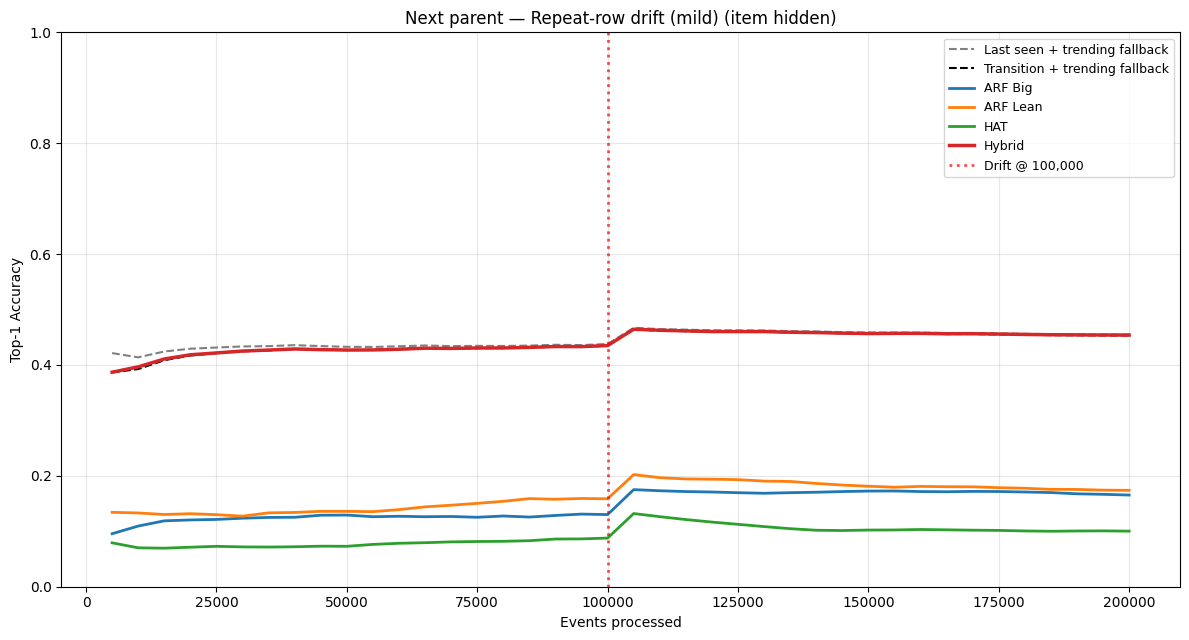


=== [Next parent] Repeat-row drift (mild) — accuracy snapshots ===
Model        |  Pre-drift | Post-drift |      Final
-----------------------------------------------------
last_seen    |     0.4378 |     0.4624 |     0.4548
transition   |     0.4347 |     0.4599 |     0.4532
arf_big      |     0.1301 |     0.1696 |     0.1654
arf_lean     |     0.1586 |     0.1932 |     0.1739
hat          |     0.0877 |     0.1126 |     0.1002
hybrid       |     0.4351 |     0.4602 |     0.4539


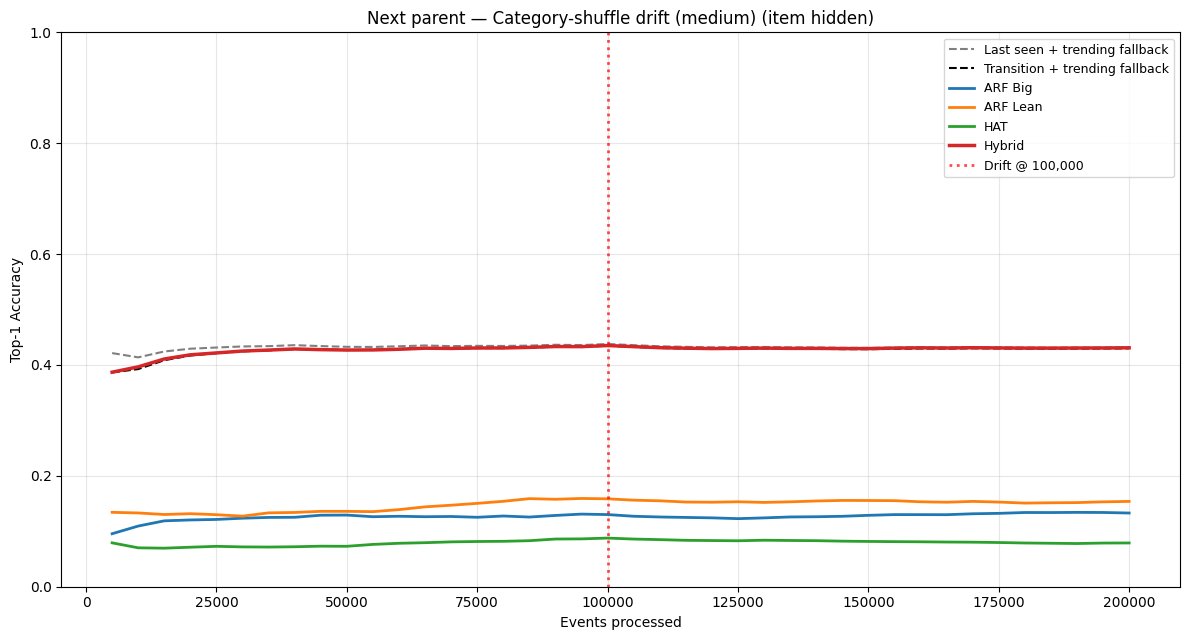


=== [Next parent] Category-shuffle drift (medium) — accuracy snapshots ===
Model        |  Pre-drift | Post-drift |      Final
-----------------------------------------------------
last_seen    |     0.4378 |     0.4322 |     0.4317
transition   |     0.4347 |     0.4294 |     0.4300
arf_big      |     0.1301 |     0.1228 |     0.1329
arf_lean     |     0.1586 |     0.1532 |     0.1539
hat          |     0.0877 |     0.0829 |     0.0789
hybrid       |     0.4351 |     0.4299 |     0.4310


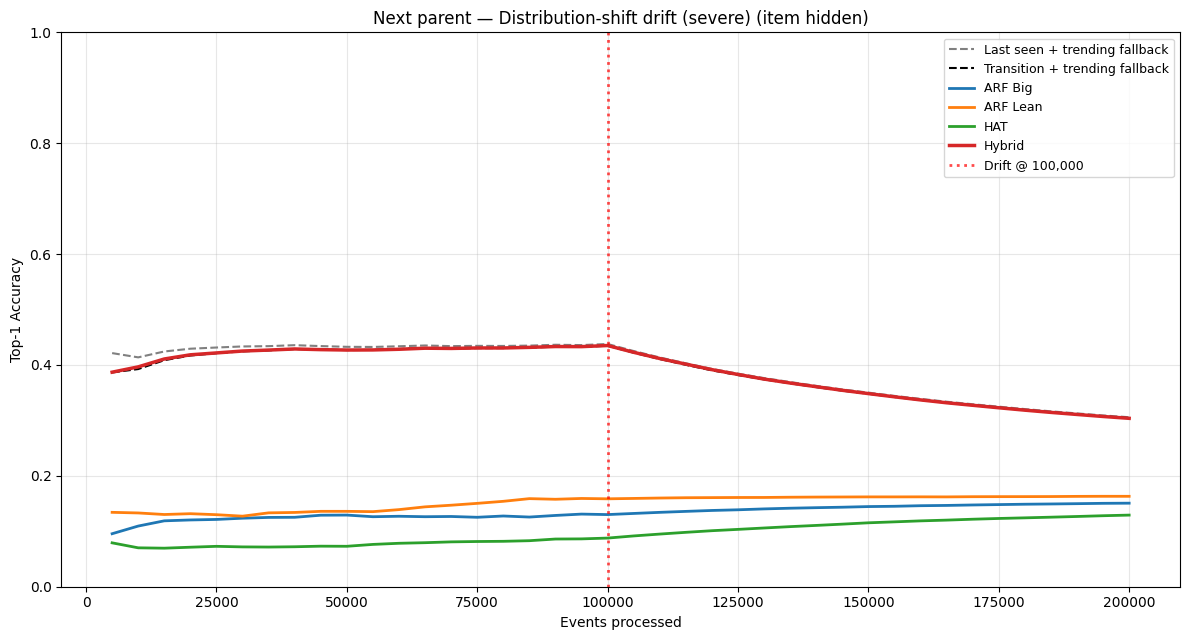


=== [Next parent] Distribution-shift drift (severe) — accuracy snapshots ===
Model        |  Pre-drift | Post-drift |      Final
-----------------------------------------------------
last_seen    |     0.4378 |     0.3843 |     0.3057
transition   |     0.4347 |     0.3818 |     0.3042
arf_big      |     0.1301 |     0.1388 |     0.1507
arf_lean     |     0.1586 |     0.1609 |     0.1631
hat          |     0.0877 |     0.1034 |     0.1292
hybrid       |     0.4351 |     0.3829 |     0.3037


In [12]:
parent_scenarios = [
    ('repeat_row',       'Repeat-row drift (mild)',           repeat_row_drift),
    ('category_shuffle', 'Category-shuffle drift (medium)',   category_shuffle_drift),
    ('distribution',     'Distribution-shift drift (severe)', distribution_shift_drift),
]

parent_results = {}
for slug, nice_name, generator in parent_scenarios:
    drift_rows = generator(BASE_ROWS)
    hist, dp = run_parent_scenario(drift_rows, nice_name, DRIFT_POINT)
    parent_results[slug] = (hist, dp, nice_name)

for slug, (hist, dp, nice_name) in parent_results.items():
    plot_parent(hist, dp, nice_name, f'parent_{slug}.png')
    before_after_table_parent(hist, dp, nice_name)


 ## 12. Run all intent scenarios


--- [Intent] Running scenario: Intent-suppression drift ---
Final intent metrics for Intent-suppression drift:
       zero: ROC=0.5000  F1=0.0000
       cart: ROC=0.9202  F1=0.1283
    arf_big: ROC=0.8835  F1=0.1598
   arf_lean: ROC=0.8630  F1=0.1524
        hat: ROC=0.8003  F1=0.0814

--- [Intent] Running scenario: Intent-boost drift ---
Final intent metrics for Intent-boost drift:
       zero: ROC=0.5000  F1=0.0000
       cart: ROC=0.6011  F1=0.1552
    arf_big: ROC=0.7239  F1=0.1087
   arf_lean: ROC=0.7204  F1=0.1091
        hat: ROC=0.6828  F1=0.1003


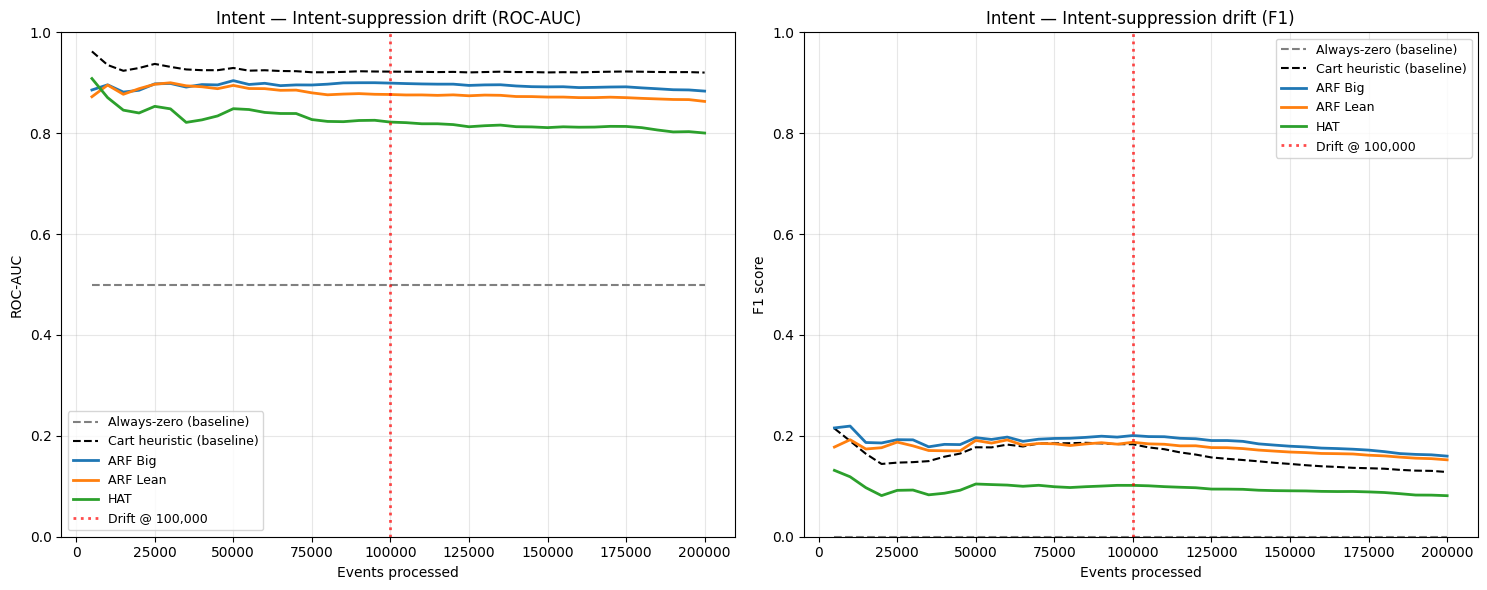


=== [Intent] Intent-suppression drift — ROC-AUC snapshots ===
Model      |  Pre-drift | Post-drift |      Final
---------------------------------------------------
zero       |     0.5000 |     0.5000 |     0.5000
cart       |     0.9221 |     0.9206 |     0.9202
arf_big    |     0.8993 |     0.8948 |     0.8835
arf_lean   |     0.8768 |     0.8742 |     0.8630
hat        |     0.8220 |     0.8128 |     0.8003


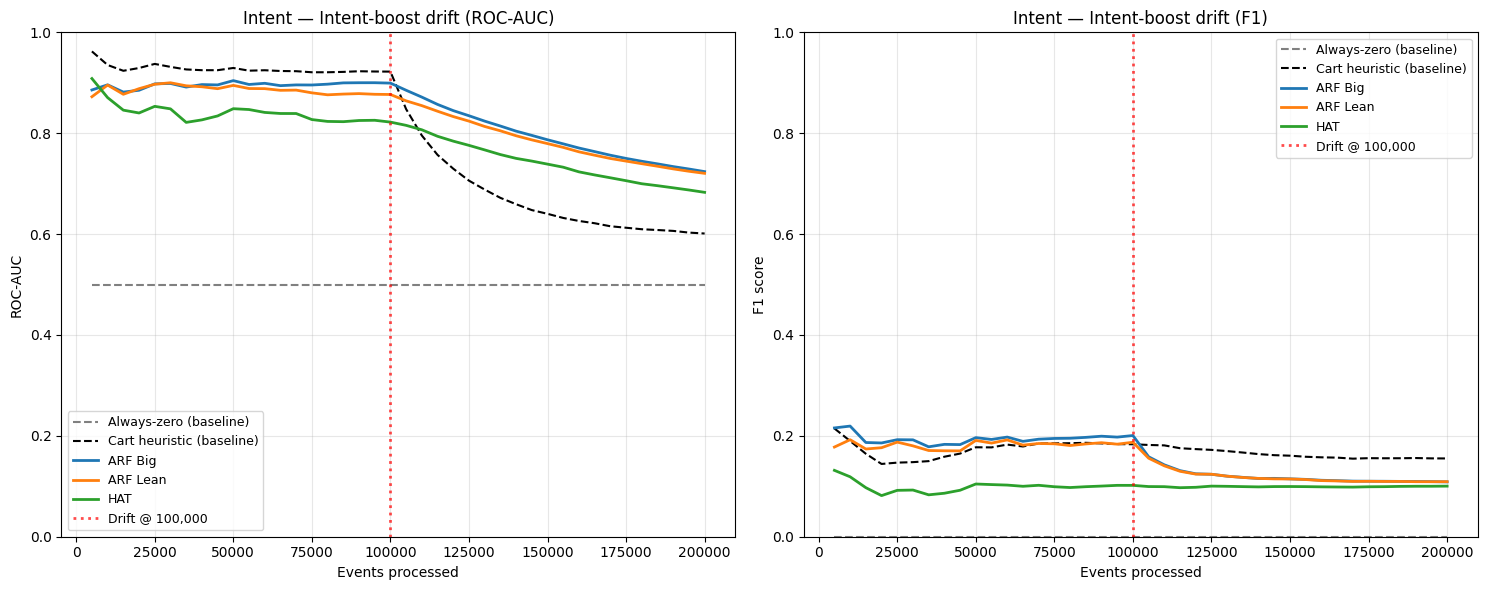


=== [Intent] Intent-boost drift — ROC-AUC snapshots ===
Model      |  Pre-drift | Post-drift |      Final
---------------------------------------------------
zero       |     0.5000 |     0.5000 |     0.5000
cart       |     0.9221 |     0.7059 |     0.6011
arf_big    |     0.8993 |     0.8346 |     0.7239
arf_lean   |     0.8768 |     0.8239 |     0.7204
hat        |     0.8220 |     0.7759 |     0.6828

All plots saved to: /Users/maciej/Desktop/MLDS_workspace/data_retailrocket/plots_drift_v3


In [13]:
intent_scenarios = [
    ('suppression', 'Intent-suppression drift', intent_suppression_drift),
    ('boost',       'Intent-boost drift',       intent_boost_drift),
]

intent_results = {}
for slug, nice_name, generator in intent_scenarios:
    drift_rows = generator(BASE_ROWS)
    hist, dp = run_intent_scenario(drift_rows, nice_name, DRIFT_POINT)
    intent_results[slug] = (hist, dp, nice_name)

for slug, (hist, dp, nice_name) in intent_results.items():
    plot_intent(hist, dp, nice_name, f'intent_{slug}.png')
    before_after_table_intent(hist, dp, nice_name)

print(f"\nAll plots saved to: {PLOT_DIR}")
